In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
sparse = pd.read_csv('data\captone_data.csv')
sparse.head()

,user,item,rating
0,1889878,CC0101EN,3.0
1,1342067,CL0101EN,3.0
2,1990814,ML0120ENv3,3.0
3,380098,BD0211EN,3.0
4,779563,DS0101EN,3.0


# **EDA**

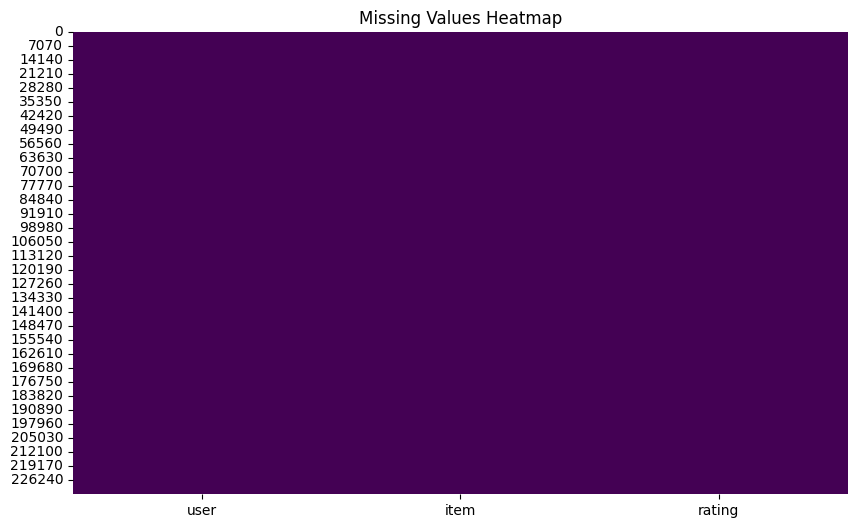

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(sparse.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

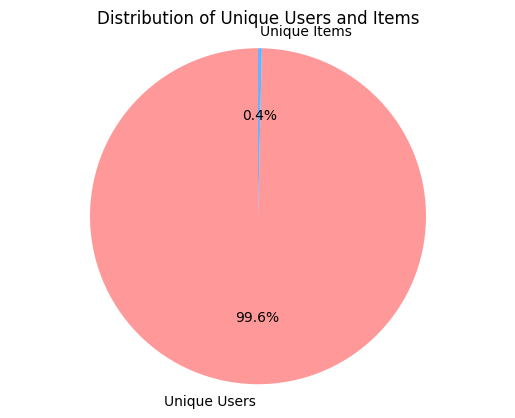

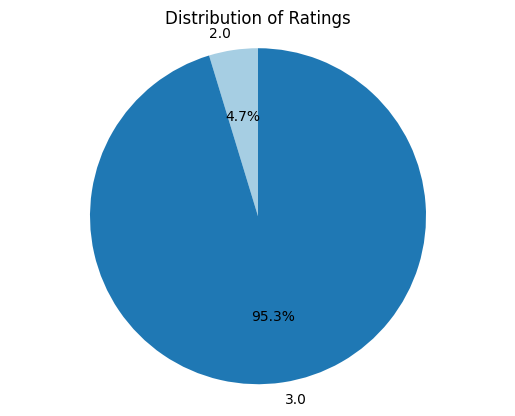

In [ ]:
unique_users = sparse['user'].nunique()
unique_items = sparse['item'].nunique()
labels = ['Unique Users', 'Unique Items']
sizes = [unique_users, unique_items]
colors = ['#ff9999','#66b3ff']
fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax1.axis('equal')
plt.title('Distribution of Unique Users and Items')
plt.show()

# Pie chart for rating distribution
rating_counts = sparse['rating'].value_counts().sort_index()
labels_rating = rating_counts.index.astype(str)
sizes_rating = rating_counts.values
colors_rating = plt.cm.Paired(np.arange(len(labels_rating))) # Using a colormap
fig2, ax2 = plt.subplots()
ax2.pie(sizes_rating, labels=labels_rating, colors=colors_rating, autopct='%1.1f%%', startangle=90)
ax2.axis('equal')
plt.title('Distribution of Ratings')
plt.show()


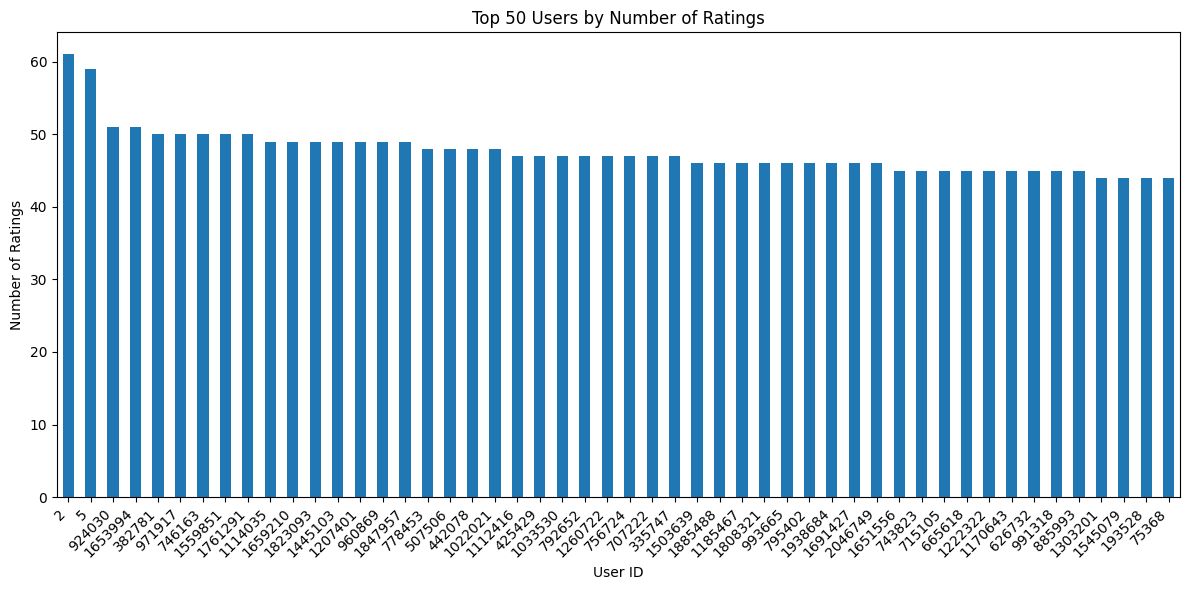

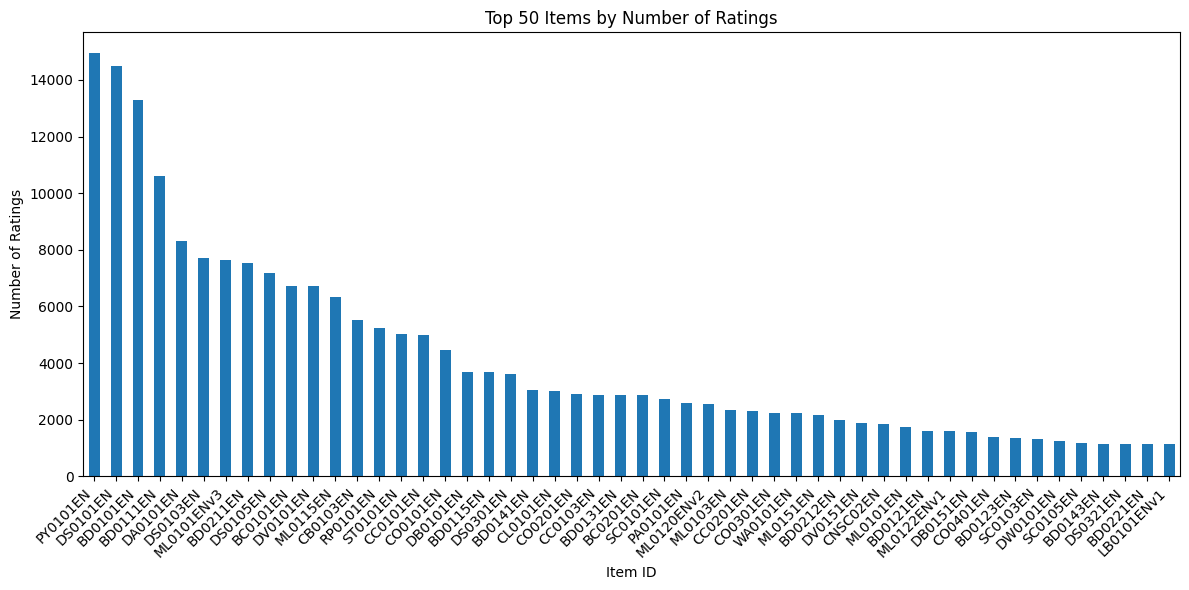

In [ ]:
user_ratings_count = sparse['user'].value_counts()
plt.figure(figsize=(12, 6))
user_ratings_count.head(50).plot(kind='bar')
plt.title('Top 50 Users by Number of Ratings')
plt.xlabel('User ID')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

item_ratings_count = sparse['item'].value_counts()
plt.figure(figsize=(12, 6))
item_ratings_count.head(50).plot(kind='bar')
plt.title('Top 50 Items by Number of Ratings')
plt.xlabel('Item ID')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

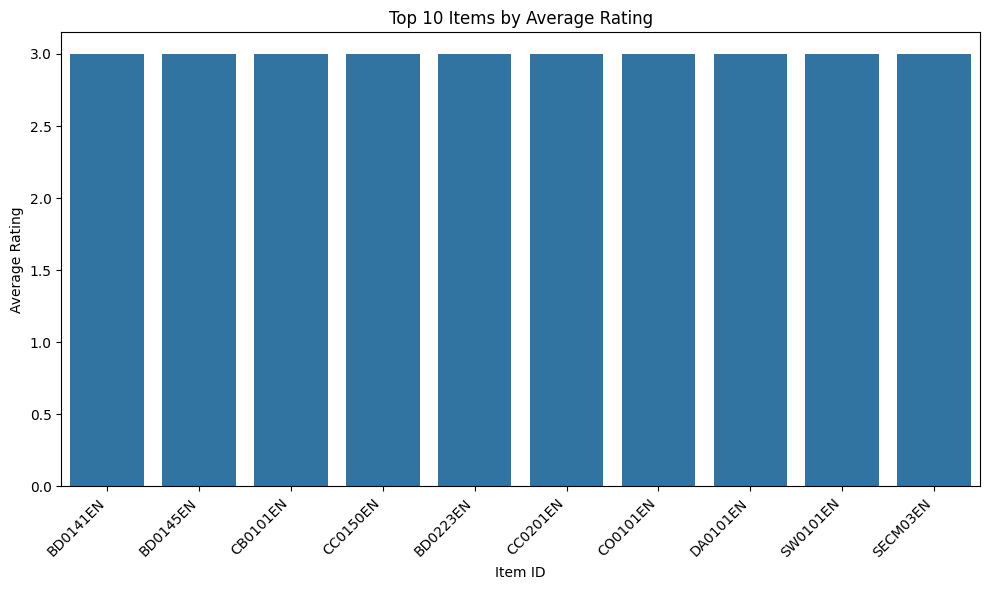

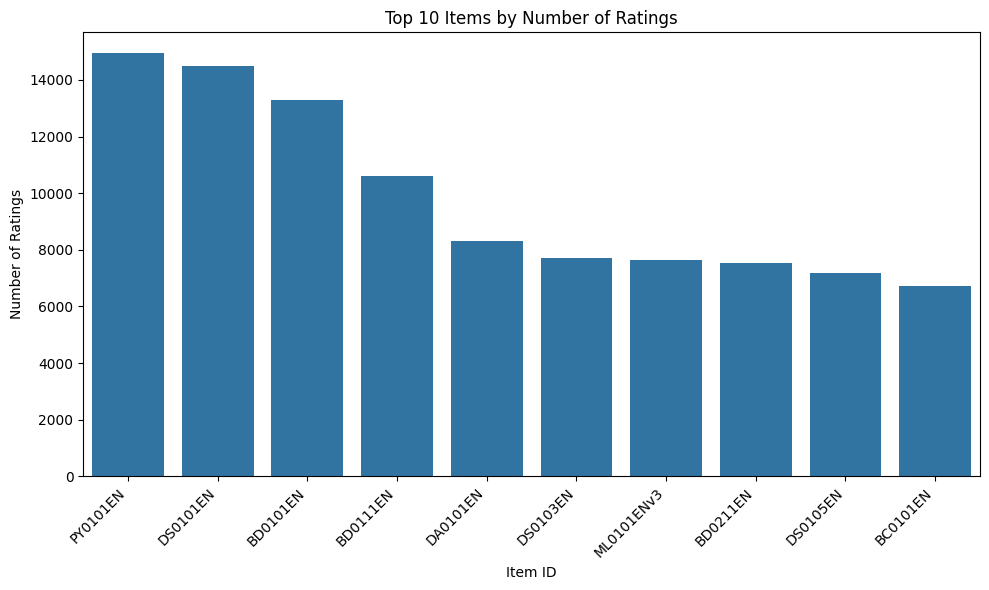

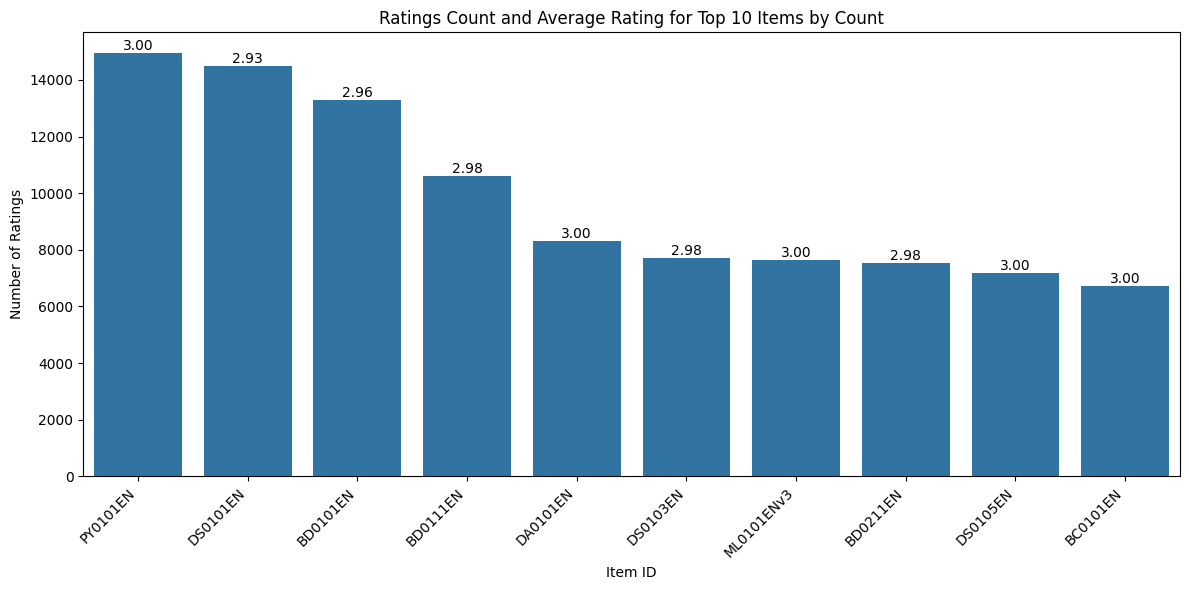

In [ ]:
average_ratings = sparse.groupby('item')['rating'].mean()
ratings_count = sparse.groupby('item').size()

item_stats = pd.DataFrame({
    'average_rating': average_ratings,
    'ratings_count': ratings_count
})

top_avg_rating_items = item_stats.sort_values(by='average_rating', ascending=False).head(10)

top_ratings_count_items = item_stats.sort_values(by='ratings_count', ascending=False).head(10)
combined_top_items = item_stats.loc[top_ratings_count_items.index]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_avg_rating_items.index, y=top_avg_rating_items['average_rating'])
plt.title('Top 10 Items by Average Rating')
plt.xlabel('Item ID')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=top_ratings_count_items.index, y=top_ratings_count_items['ratings_count'])
plt.title('Top 10 Items by Number of Ratings')
plt.xlabel('Item ID')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=combined_top_items.index, y=combined_top_items['ratings_count'])
plt.title('Ratings Count and Average Rating for Top 10 Items by Count')
plt.xlabel('Item ID')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45, ha='right')

for container in ax.containers:
    for i, bar in enumerate(container):
        height = bar.get_height()
        avg_rating = combined_top_items['average_rating'].iloc[i]
        ax.text(bar.get_x() + bar.get_width() / 2., height,
                f'{avg_rating:.2f}',
                ha='center', va='bottom', color='black', fontsize=10)

plt.tight_layout()
plt.show()

# **Feature engineering**

In [4]:
utility = sparse.pivot(index='user', columns='item', values='rating')
utility.iloc[:5, :5]

item,AI0111EN,BC0101EN,BC0201EN,BC0202EN,BD0101EN
user,,,,,
2,NaN,3.0,NaN,NaN,3.0
4,NaN,NaN,NaN,NaN,2.0
5,2.0,2.0,2.0,NaN,2.0
7,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN


**User-User**

In [46]:
user_sparse_norm = sparse.copy()
user_mean_ratings = user_sparse_norm.groupby('user')['rating'].mean()

user_sparse_norm['rating'] = user_sparse_norm.apply(
            lambda row: row['rating'] - user_mean_ratings[row['user']],
            axis=1
)
user_utility_norm = user_sparse_norm.pivot(index='user', columns='item', values='rating').fillna(0)
user_utility_norm.iloc[:5, :5]

item,AI0111EN,BC0101EN,BC0201EN,BC0202EN,BD0101EN
user,,,,,
2,0.0,0.295082,0.0,0.0,0.295082
4,0.0,0.000000,0.0,0.0,0.000000
5,0.0,0.000000,0.0,0.0,0.000000
7,0.0,0.000000,0.0,0.0,0.000000
8,0.0,0.000000,0.0,0.0,0.000000


**Item-Item**

In [47]:
item_sparse_norm = sparse.copy()
item_mean_ratings = item_sparse_norm.groupby('item')['rating'].mean()

item_sparse_norm['rating'] = item_sparse_norm.apply(
            lambda row: row['rating'] - item_mean_ratings[row['item']],
            axis=1
)
item_utility_norm = item_sparse_norm.pivot(index='item', columns='user', values='rating').fillna(0)
item_utility_norm.iloc[:5, :5]

user,2,4,5,7,8
item,,,,,
AI0111EN,0.000000,0.000000,-0.997389,0.0,0.0
BC0101EN,0.000149,0.000000,-0.999851,0.0,0.0
BC0201EN,0.000000,0.000000,-0.643754,0.0,0.0
BC0202EN,0.000000,0.000000,0.000000,0.0,0.0
BD0101EN,0.039425,-0.960575,-0.960575,0.0,0.0


# **Preprocessing**

In [ ]:
def train_test_split_iiCF(sparse, k=1, seed=42):
    train_list = []
    test_list = []
    grouped = sparse.groupby('user')

    for user, group in grouped:
        if len(group) <= k:
            train_list.append(group)
        else:
            group = group.sample(frac=1, random_state=seed)
            test_part = group.iloc[:k]
            train_part = group.iloc[k:]
            train_list.append(train_part)
            test_list.append(test_part)

    train_df = pd.concat(train_list).reset_index(drop=True)
    test_df = pd.concat(test_list).reset_index(drop=True)

    # Kiểm tra xem test users và items có trong train không
    test_users = set(test_df['user'].unique())
    train_users = set(train_df['user'].unique())
    test_items = set(test_df['item'].unique())
    train_items = set(train_df['item'].unique())

    unseen_users = test_users - train_users
    unseen_items = test_items - train_items

    if unseen_users or unseen_items:
        print("⚠️ Cảnh báo: Có user hoặc item trong test nhưng không có trong train.")
        print(f"Unseen users: {unseen_users}")
        print(f"Unseen items: {unseen_items}")
    else:
        print("✅ Đảm bảo không có user/item mới trong test.")

    return train_df, test_df

In [4]:
sparse_train, sparse_test = train_test_split_iiCF(sparse, k=2)

print(f"Train shape: {sparse_train.shape}")
print(f"Test shape: {sparse_test.shape}")
print(f"Uinique users in train: {sparse_train['user'].unique().size}")
print(f"Uinique items in train: {sparse_train['item'].unique().size}")
print(f"Uinique users in test: {sparse_test['user'].unique().size}")
print(f"Uinique items in test: {sparse_test['item'].unique().size}")

✅ Đảm bảo không có user/item mới trong test.
Train shape: (182908, 3)
Test shape: (50398, 3)
Uinique users in train: 33901
Uinique items in train: 126
Uinique users in test: 25199
Uinique items in test: 117


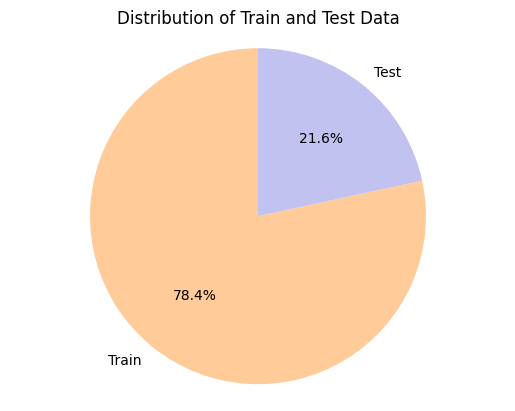

In [5]:
labels = ['Train', 'Test']
sizes = [len(sparse_train), len(sparse_test)]
colors = ['#ffcc99','#c2c2f0']
fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax1.axis('equal')
plt.title('Distribution of Train and Test Data')
plt.show()

In [6]:
def plot_unique_distribution(df, title):
    unique_users = df['user'].nunique()
    unique_items = df['item'].nunique()
    labels = ['Unique Users', 'Unique Items']
    sizes = [unique_users, unique_items]
    colors = ['#ff9999','#66b3ff']
    fig, ax = plt.subplots()
    ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    ax.axis('equal')
    plt.title(title)
    plt.show()

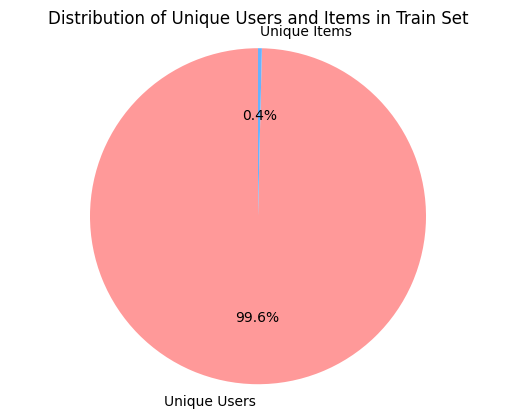

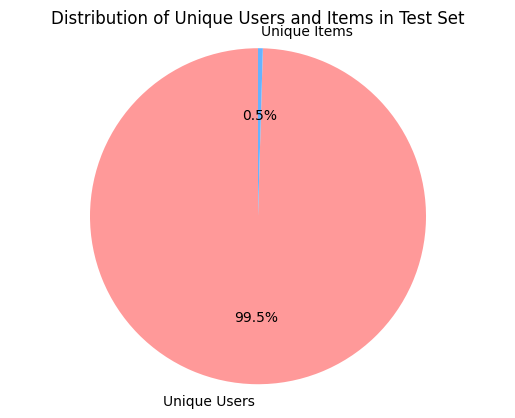

In [7]:
plot_unique_distribution(sparse_train, 'Distribution of Unique Users and Items in Train Set')
plot_unique_distribution(sparse_test, 'Distribution of Unique Users and Items in Test Set')

# **Model**

In [8]:
def get_items_rated_by_user(sparse, user):
    user_rated = sparse[sparse['user'] == user][['item', 'rating']]
    items = user_rated['item'].to_numpy()
    ratings = user_rated['rating'].to_numpy()

    return items, ratings

In [9]:
class knnCF:
    def __init__(self, sparse, uuCF=1):
        self.uuCF = uuCF
        if self.uuCF:
          self.sparse = sparse
        else:
          self.sparse = sparse.rename(columns={'user': 'item', 'item': 'user'})

        self.mean_ratings = self.sparse.groupby('user')['rating'].mean()

        self.users = sparse.iloc[:, 0].unique()
        self.items = sparse.iloc[:, 1].unique()

        self.simi_matrix = None
        self.utility_norm = None

    def train(self):
        sparse_norm = self.sparse.copy()
        sparse_norm['rating'] = sparse_norm.apply(
                    lambda row: row['rating'] - self.mean_ratings[row['user']],
                    axis=1
        )
        self.utility_norm = sparse_norm.pivot(index='user', columns='item', values='rating').fillna(0)

        simi_matrix = cosine_similarity(self.utility_norm)
        self.simi_matrix = pd.DataFrame(simi_matrix, index=self.utility_norm.index, columns=self.utility_norm.index)

    def predict(self, item, user, k=9):
        if item not in self.items or user not in self.users:
            return 0

        target = item if self.uuCF else user
        item_rated_user = self.sparse[self.sparse['item'] == target]['user'].unique()
        if len(item_rated_user) == 0:
            return 0

        target2 = user if self.uuCF else item
        sim_scores = self.simi_matrix.loc[target2, item_rated_user]
        nearest_s = sim_scores.sort_values(ascending=False).head(k)

        ratings = []
        rs = self.utility_norm.loc[nearest_s.index, target]
        ratings.extend(rs)
        ratings = np.array(ratings)

        pred_rating = np.dot(ratings, nearest_s.values) / (np.abs(nearest_s.values).sum() + 1e-8) + self.mean_ratings.loc[target2]
        return pred_rating

    def evaluate(self, sparse, k=9, return_result=False):
        truth = []
        predict = []
        for user in self.users:
            items, ratings = get_items_rated_by_user(sparse, user)
            if len(items) == 0:
                continue

            ratings_pred = [self.predict(item, user, k) for item in items]
            truth.extend(ratings)
            predict.extend(ratings_pred)

        mae = mean_absolute_error(truth, predict)
        mse = mean_squared_error(truth, predict)
        r2 = r2_score(truth, predict)
        rmse = np.sqrt(mse)

        if return_result:
            return pd.DataFrame({
                'truth': truth,
                'predict': predict
            }), mae, mse, rmse, r2
        return mae, mse, rmse, r2

In [10]:
uuCF = knnCF(sparse_train, uuCF=1)
iiCF = knnCF(sparse_train, uuCF=0)

# **Training**

**User-User**

In [11]:
uuCF.train()
uuCF.simi_matrix.iloc[:10, :10]

MemoryError: Unable to allocate 8.56 GiB for an array with shape (33901, 33901) and data type float64

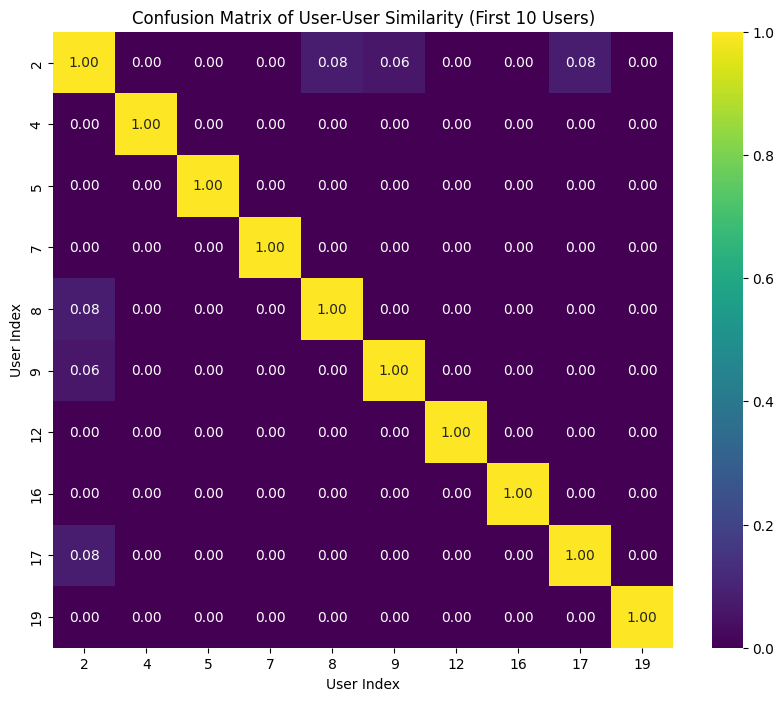

In [17]:
np.fill_diagonal(uuCF.simi_matrix.values, 1)

plt.figure(figsize=(10, 8))
sns.heatmap(uuCF.simi_matrix.iloc[:10, :10], annot=True, cmap='viridis', fmt=".2f")
plt.title('Confusion Matrix of User-User Similarity (First 10 Users)')
plt.xlabel('User Index')
plt.ylabel('User Index')
plt.show()

**Item-Item**

In [12]:
iiCF.train()
iiCF.simi_matrix.iloc[:10, :10]

user,AI0111EN,BC0101EN,BC0201EN,BC0202EN,BD0101EN,BD0111EN,BD0115EN,BD0121EN,BD0123EN,BD0131EN
user,,,,,,,,,,
AI0111EN,1.000000,0.998331,0.028496,0.000374,0.045289,0.000684,0.000313,0.000252,0.351950,0.000207
BC0101EN,0.998331,1.000000,0.027040,0.000128,0.045277,0.000528,0.000192,0.000098,0.352346,0.000135
BC0201EN,0.028496,0.027040,1.000000,0.032338,0.021152,0.011823,0.006476,0.004334,0.013441,0.004003
BC0202EN,0.000374,0.000128,0.032338,1.000000,0.000854,0.000505,0.000293,0.000309,0.000283,0.000211
BD0101EN,0.045289,0.045277,0.021152,0.000854,1.000000,0.230530,0.081798,0.066148,0.034553,0.062272
BD0111EN,0.000684,0.000528,0.011823,0.000505,0.230530,1.000000,0.193644,0.181001,0.077022,0.149388
BD0115EN,0.000313,0.000192,0.006476,0.000293,0.081798,0.193644,1.000000,0.269397,0.177992,0.217820
BD0121EN,0.000252,0.000098,0.004334,0.000309,0.066148,0.181001,0.269397,1.000000,0.164134,0.237659
BD0123EN,0.351950,0.352346,0.013441,0.000283,0.034553,0.077022,0.177992,0.164134,1.000000,0.364593


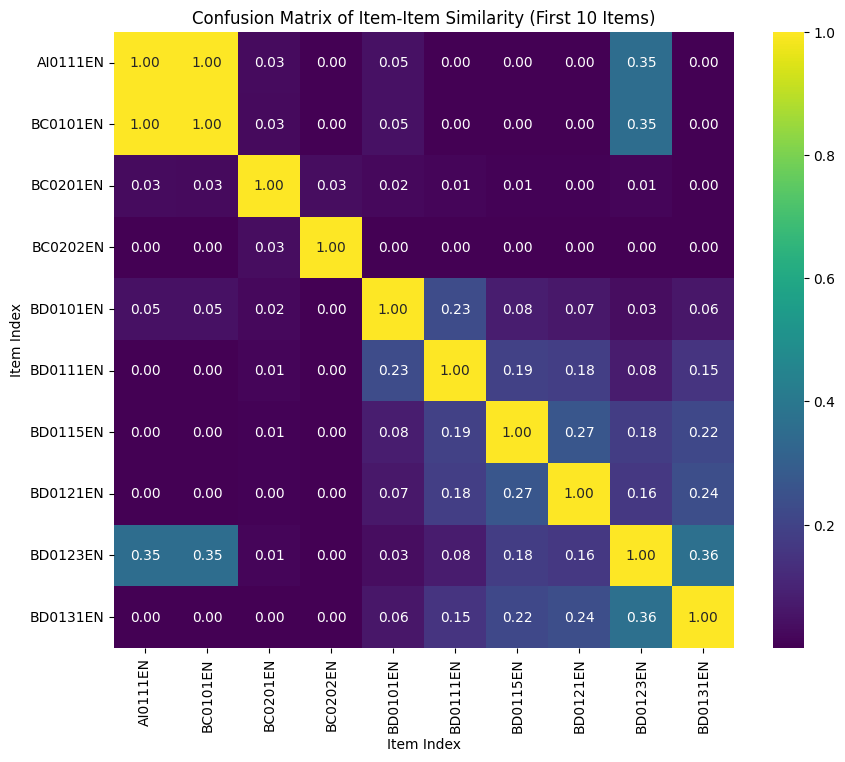

In [13]:
np.fill_diagonal(iiCF.simi_matrix.values, 1)

plt.figure(figsize=(10, 8))
sns.heatmap(iiCF.simi_matrix.iloc[:10, :10], annot=True, cmap='viridis', fmt=".2f")
plt.title('Confusion Matrix of Item-Item Similarity (First 10 Items)')
plt.xlabel('Item Index')
plt.ylabel('Item Index')
plt.show()

# **Evaluate**

In [14]:
def plot_three_lines(pd_train, pd_test, n_samples=300):
    # Lấy mẫu để dễ quan sát (nếu cần)
    pd_train_sample = pd_train.sample(n=min(n_samples, len(pd_train))).sort_index()
    pd_test_sample = pd_test.sample(n=min(n_samples, len(pd_test))).sort_index()

    plt.figure(figsize=(14, 6))

    # Vẽ 3 đường
    plt.plot(pd_test_sample['truth'].values, label='Ground Truth (Test)', linewidth=2, color='black')
    plt.plot(pd_train_sample['predict'].values, label='Predicted (Train)', linewidth=2, linestyle='--', color='blue')
    plt.plot(pd_test_sample['predict'].values, label='Predicted (Test)', linewidth=2, linestyle='--', color='red')

    plt.title('So sánh Ground Truth và Dự đoán (Train/Test)')
    plt.xlabel('Sample Index')
    plt.ylabel('Rating')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [15]:
def find_best_k(model, sparse, k_range=range(1, 21)):
    rmse_list = []
    ks = list(k_range)

    for k in ks:
        _, _, rmse, _ = model.evaluate(sparse, k=k)
        rmse_list.append(rmse)
        print(f"k = {k}, RMSE = {rmse:.4f}")

    # Tìm k tốt nhất
    best_k = ks[int(np.argmin(rmse_list))]
    return ks, best_k, rmse_list

In [16]:
def plot_k(ks, rmse_list):
    plt.figure(figsize=(10, 5))
    plt.plot(ks, rmse_list, marker='o', linestyle='-', color='blue')
    plt.title('RMSE theo số lượng hàng xóm k')
    plt.xlabel('k (số lượng hàng xóm)')
    plt.ylabel('RMSE')
    plt.xticks(ks)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [23]:
def plot_comparison_lines(pd_train_uu, pd_train_ii, pd_test_uu, pd_test_ii, n_samples=300):
    # Sample data
    pd_train_uu_sample = pd_train_uu.sample(n=min(n_samples, len(pd_train_uu))).sort_index()
    pd_train_ii_sample = pd_train_ii.sample(n=min(n_samples, len(pd_train_ii))).sort_index()
    pd_test_uu_sample = pd_test_uu.sample(n=min(n_samples, len(pd_test_uu))).sort_index()
    pd_test_ii_sample = pd_test_ii.sample(n=min(n_samples, len(pd_test_ii))).sort_index()

    # Plot for Train Set
    plt.figure(figsize=(14, 6))
    plt.plot(pd_train_uu_sample['truth'].values, label='Ground Truth (Train)', linewidth=2, color='black')
    plt.plot(pd_train_uu_sample['predict'].values, label='UU Predict (Train)', linewidth=2, linestyle='--', color='blue')
    plt.plot(pd_train_ii_sample['predict'].values, label='II Predict (Train)', linewidth=2, linestyle='--', color='red')
    plt.title('So sánh Ground Truth, UU Predict và II Predict (Tập Train)')
    plt.xlabel('Sample Index')
    plt.ylabel('Rating')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot for Test Set
    plt.figure(figsize=(14, 6))
    plt.plot(pd_test_uu_sample['truth'].values, label='Ground Truth (Test)', linewidth=2, color='black')
    plt.plot(pd_test_uu_sample['predict'].values, label='UU Predict (Test)', linewidth=2, linestyle='--', color='blue')
    plt.plot(pd_test_ii_sample['predict'].values, label='II Predict (Test)', linewidth=2, linestyle='--', color='red')
    plt.title('So sánh Ground Truth, UU Predict và II Predict (Tập Test)')
    plt.xlabel('Sample Index')
    plt.ylabel('Rating')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

**User-User**

In [17]:
ks_uu, best_k_uu, rmse_list_uu = find_best_k(uuCF, sparse_test, k_range=range(2, 21, 2))
print(f"\n✅ Best k = {best_k_uu} with RMSE = {min(rmse_list_uu):.4f}")

AttributeError: 'NoneType' object has no attribute 'loc'

In [ ]:
plot_k(ks_uu, rmse_list_uu)

In [ ]:
pd_train_uu, mae_train_uu, mse_train_uu, rmse_train_uu, r2_train_uu = uuCF.evaluate(sparse_train, k=best_k_uu, return_result=True)
pd_test_uu, mae_test_uu, mse_test_uu, rmse_test_uu, r2_ttest_uu = uuCF.evaluate(sparse_test, k=best_k_uu, return_result=True)

KeyboardInterrupt: 

In [ ]:
plot_three_lines(pd_train_uu, pd_test_uu, n_samples=10)

**Item-Item**

In [18]:
ks_ii, best_k_ii, rmse_list_ii = find_best_k(iiCF, sparse_test, k_range=range(1, 31, 2))
print(f"\n✅ Best k = {best_k_ii} with RMSE = {min(rmse_list_ii):.4f}")

k = 1, RMSE = 0.1052
k = 3, RMSE = 0.0968
k = 5, RMSE = 0.0961
k = 7, RMSE = 0.0959
k = 9, RMSE = 0.0959
k = 11, RMSE = 0.0958
k = 13, RMSE = 0.0958
k = 15, RMSE = 0.0958
k = 17, RMSE = 0.0958
k = 19, RMSE = 0.0958
k = 21, RMSE = 0.0958
k = 23, RMSE = 0.0958
k = 25, RMSE = 0.0958
k = 27, RMSE = 0.0958
k = 29, RMSE = 0.0958

✅ Best k = 27 with RMSE = 0.0958


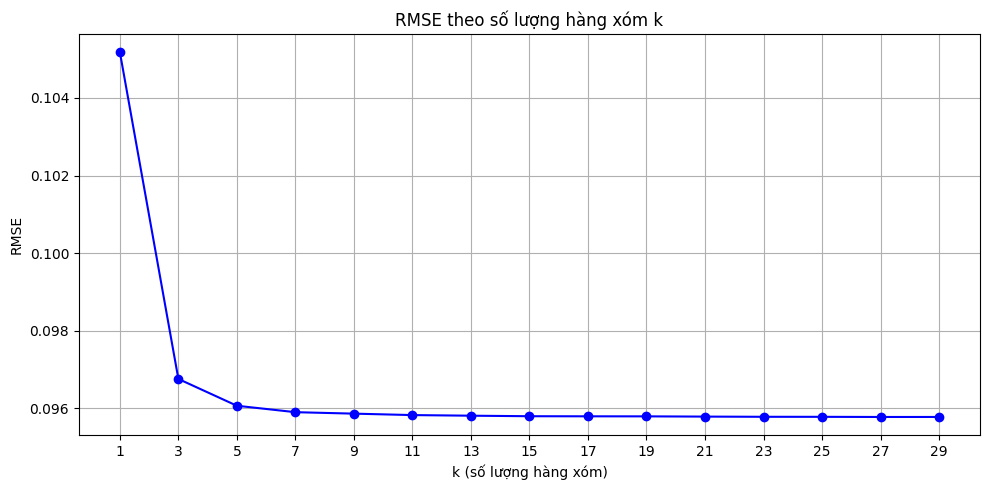

In [19]:
plot_k(ks_ii, rmse_list_ii)

In [20]:
pd_train_ii, mae_train_ii, mse_train_ii, rmse_train_ii, r2_train_ii = iiCF.evaluate(sparse_train, k=best_k_ii, return_result=True)
pd_test_ii, mae_test_ii, mse_test_ii, rmse_test_ii, r2_ttest_ii = iiCF.evaluate(sparse_test, k=best_k_ii, return_result=True)

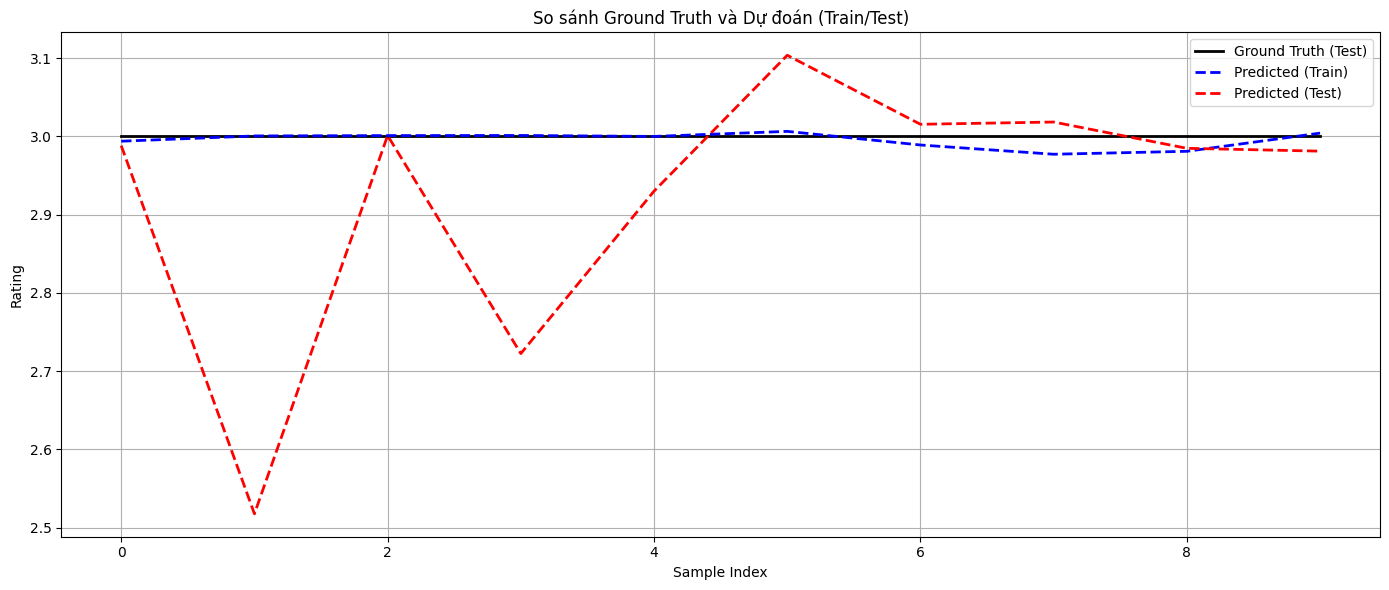

In [21]:
plot_three_lines(pd_train_ii, pd_test_ii, n_samples=10)

**Compare**

In [ ]:
train_performance = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'User-User CF (Train)': [mae_train_uu, mse_train_uu, rmse_train_uu, r2_train_uu],
    'Item-Item CF (Train)': [mae_train_ii, mse_train_ii, rmse_train_ii, r2_train_ii]
}
df_train_performance = pd.DataFrame(train_performance)

# Prepare performance data for Test set
test_performance = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'User-User CF (Test)': [mae_test_uu, mse_test_uu, rmse_test_uu, r2_ttest_uu], # Corrected variable name r2_ttest_uu
    'Item-Item CF (Test)': [mae_test_ii, mse_test_ii, rmse_test_ii, r2_ttest_ii] # Corrected variable name r2_ttest_ii
}
df_test_performance = pd.DataFrame(test_performance)

# Display the tables
print("Performance Metrics on Training Set:")
print(df_train_performance.to_markdown(index=False))

print("\nPerformance Metrics on Test Set:")
print(df_test_performance.to_markdown(index=False))

In [ ]:
plot_comparison_lines(pd_train_uu, pd_train_ii, pd_test_uu, pd_test_ii, n_samples=100)